# Finance-Specific Synthetic Dataset Version

In [1]:
import pandas as pd
import numpy as np

# Load finance-specific synthetic dataset
df_fin = pd.read_csv("financial_fraud_synthetic.csv")

df_fin['timestamp'] = pd.to_datetime(df_fin['timestamp'])

# Sort by account and time
df_fin = df_fin.sort_values(['account_id', 'timestamp']).reset_index(drop=True)

# Time gap feature
df_fin['prev_timestamp'] = df_fin.groupby('account_id')['timestamp'].shift(1)
df_fin['time_gap_minutes'] = (df_fin['timestamp'] - df_fin['prev_timestamp']).dt.total_seconds() / 60
df_fin['time_gap_minutes'] = df_fin['time_gap_minutes'].fillna(1440)

# Account transaction count
df_fin['account_txn_count'] = df_fin.groupby('account_id').cumcount() + 1

# Account average amount and deviation
df_fin['account_avg_amount'] = df_fin.groupby('account_id')['amount'].transform('mean')
df_fin['amount_deviation'] = df_fin['amount'] - df_fin['account_avg_amount']

# Finance-specific feature set for Mahalanobis
features_fin = [
    'amount',
    'time_gap_minutes',
    'account_txn_count',
    'amount_deviation',
    'is_international',
    'failed_login_count',
    'device_change_flag',
    'ip_risk_score',
    'amount_to_balance_ratio',
    'new_beneficiary_flag'
]

X_fin = df_fin[features_fin]

# Mean vector and covariance matrix
mu_fin = X_fin.mean()
Sigma_fin = X_fin.cov()

mu_fin_np = mu_fin.values
Sigma_fin_np = Sigma_fin.values
Sigma_fin_inv = np.linalg.inv(Sigma_fin_np)

# Mahalanobis scores
X_fin_np = X_fin.values
mahalanobis_scores_fin = []

for i in range(len(X_fin_np)):
    diff = X_fin_np[i] - mu_fin_np
    score = np.sqrt(diff.T @ Sigma_fin_inv @ diff)
    mahalanobis_scores_fin.append(score)

df_fin['mahalanobis_score'] = mahalanobis_scores_fin

# EWMA on amount per account
df_fin['ewma_amount'] = df_fin.groupby('account_id')['amount'].transform(
    lambda x: x.ewm(alpha=0.3).mean()
)

df_fin['ewma_deviation'] = abs(df_fin['amount'] - df_fin['ewma_amount'])

# Normalize scores
df_fin['mah_norm'] = df_fin['mahalanobis_score'] / df_fin['mahalanobis_score'].max()
df_fin['ewma_norm'] = df_fin['ewma_deviation'] / df_fin['ewma_deviation'].max()

# Final combined risk score
df_fin['final_risk_score'] = 0.6 * df_fin['mah_norm'] + 0.4 * df_fin['ewma_norm']

# Risk bands
df_fin['risk_level'] = pd.cut(
    df_fin['final_risk_score'],
    bins=[0, 0.4, 0.7, 1],
    labels=['Low', 'Medium', 'High']
)

# Show result preview
df_fin[['account_id', 'amount', 'mahalanobis_score', 'ewma_deviation', 'final_risk_score', 'risk_level']].head(10)

,account_id,amount,mahalanobis_score,ewma_deviation,final_risk_score,risk_level
0,A1000,11389.33,2.426866,0.000000,0.144471,Low
1,A1000,9580.84,2.225664,744.672353,0.141617,Low
2,A1000,10944.40,4.145290,336.290548,0.250889,Low
3,A1000,8698.58,4.685849,1155.668634,0.293106,Low
4,A1000,7248.72,2.513084,1665.956086,0.170014,Low
5,A1000,11338.79,1.847896,1599.913370,0.129606,Low
6,A1000,11096.86,1.988414,914.026611,0.129568,Low
7,A1000,13650.43,1.941427,2363.678973,0.144531,Low
8,A1000,19735.09,5.606794,5807.260227,0.404918,Medium
9,A1000,10820.91,1.499661,2147.749659,0.115587,Low


In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt

account_dropdown = widgets.Dropdown(
    options=sorted(df_fin['account_id'].unique()),
    description='Account:'
)

output = widgets.Output()

def show_account(change):
    with output:
        clear_output(wait=True)
        account_choice = account_dropdown.value
        acc_df = df_fin[df_fin['account_id'] == account_choice].copy()

        print("Account selected:", account_choice)
        print("Number of transactions:", len(acc_df))
        print("Average risk score:", acc_df['final_risk_score'].mean())
        print("Maximum risk score:", acc_df['final_risk_score'].max())
        print("Average Mahalanobis score:", acc_df['mahalanobis_score'].mean())
        print("Maximum Mahalanobis score:", acc_df['mahalanobis_score'].max())

        display(
            acc_df[[
                'account_id', 'timestamp', 'amount', 'is_international',
                'failed_login_count', 'device_change_flag',
                'new_beneficiary_flag', 'mahalanobis_score',
                'ewma_deviation', 'final_risk_score', 'risk_level'
            ]].sort_values('timestamp')
        )

        # Graph 1: Amount vs EWMA
        plt.figure()
        plt.plot(acc_df['timestamp'], acc_df['amount'], label='Actual Amount')
        plt.plot(acc_df['timestamp'], acc_df['ewma_amount'], label='EWMA Trend')
        plt.title(f"Amount vs EWMA for Account {account_choice}")
        plt.xlabel("Time")
        plt.ylabel("Transaction Amount")
        plt.legend()
        plt.xticks(rotation=45)
        plt.show()

        # Graph 2: Mahalanobis score over time for this account
        plt.figure()
        plt.plot(acc_df['timestamp'], acc_df['mahalanobis_score'], marker='o')
        plt.title(f"Mahalanobis Score Over Time for Account {account_choice}")
        plt.xlabel("Time")
        plt.ylabel("Mahalanobis Score")
        plt.xticks(rotation=45)
        plt.show()

        # Graph 3: Mahalanobis score distribution for this account
        plt.figure()
        plt.hist(acc_df['mahalanobis_score'], bins=10)
        plt.title(f"Mahalanobis Score Distribution for Account {account_choice}")
        plt.xlabel("Mahalanobis Score")
        plt.ylabel("Frequency")
        plt.show()

        display(
            acc_df.sort_values('final_risk_score', ascending=False)[[
                'account_id', 'timestamp', 'amount', 'is_international',
                'failed_login_count', 'device_change_flag',
                'new_beneficiary_flag', 'mahalanobis_score',
                'ewma_deviation', 'final_risk_score', 'risk_level'
            ]].head(10)
        )

account_dropdown.observe(show_account, names='value')
display(account_dropdown, output)
show_account(None)

Dropdown(description='Account:', options=('A1000', 'A1001', 'A1002', 'A1003', 'A1004', 'A1005', 'A1006', 'A100…

Output()

In [3]:
df_fin['risk_level'].value_counts()

risk_level
Low       2323
Medium     159
High        18
Name: count, dtype: int64

In [4]:
df_fin.sort_values('final_risk_score', ascending=False)[
    ['account_id', 'amount', 'is_international', 'failed_login_count',
     'device_change_flag', 'new_beneficiary_flag',
     'final_risk_score', 'risk_level']
].head(10)

,account_id,amount,is_international,failed_login_count,device_change_flag,new_beneficiary_flag,final_risk_score,risk_level
1442,A1046,59003.49,0,1,1,1,1.000000,High
327,A1011,54428.33,0,0,1,1,0.944796,High
14,A1000,51901.61,0,0,1,1,0.909956,High
1609,A1051,53560.85,0,1,1,1,0.853506,High
328,A1011,53678.53,0,3,0,1,0.811510,High
1237,A1040,49071.26,0,1,1,1,0.805856,High
914,A1029,46391.13,0,2,1,1,0.787033,High
1319,A1042,46514.50,0,3,1,1,0.772816,High
1858,A1059,50171.73,0,3,1,1,0.769584,High
1464,A1046,43983.72,1,6,1,1,0.752161,High


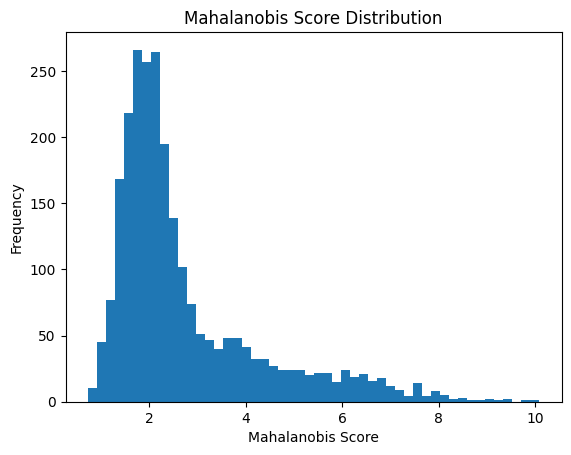

In [5]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df_fin['mahalanobis_score'], bins=50)
plt.title("Mahalanobis Score Distribution")
plt.xlabel("Mahalanobis Score")
plt.ylabel("Frequency")
plt.show()

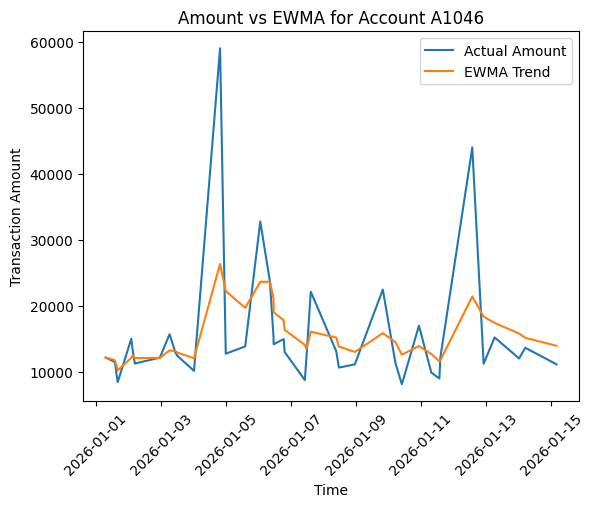

In [6]:
top_account = df_fin.sort_values('final_risk_score', ascending=False).iloc[0]['account_id']

sample_acc = df_fin[df_fin['account_id'] == top_account].copy()

plt.figure()
plt.plot(sample_acc['timestamp'], sample_acc['amount'], label='Actual Amount')
plt.plot(sample_acc['timestamp'], sample_acc['ewma_amount'], label='EWMA Trend')
plt.title(f"Amount vs EWMA for Account {top_account}")
plt.xlabel("Time")
plt.ylabel("Transaction Amount")
plt.legend()
plt.xticks(rotation=45)
plt.show()

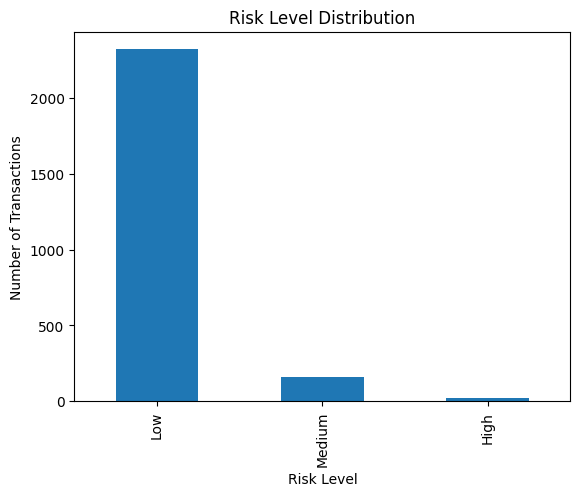

In [7]:
df_fin['risk_level'].value_counts().plot(kind='bar')
plt.title("Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Transactions")
plt.show()